# OpenTRIM "2 MeV Fe on Fe" example

This notebook shows how to run the "2 MeV Fe on Fe" example from OpenTRIM's GUI using Python.

Basic steps:
- JSON configuration is prepared in Python and saved to a file
- `opentrim` command-line executable is called with the JSON input
- HDF5 output file is opened with `h5py`
- Data plots are created with `matplotlib`

It is assumed that `opentrim` is available on your `PATH`. If it is not, set `exe` to the full path (example in the comment below).

## 1. Load required Python modules

In [14]:
from pathlib import Path
import json
import subprocess
import tempfile
from typing import Any, Dict

import h5py
import numpy as np
import matplotlib.pyplot as plt

# 2. Generate the standard json configuration template.

Using OpenTRIM's `-t` CLI option

In [15]:
exe = "opentrim"
cmd = [exe, "-t"]

template_run = subprocess.run(
    cmd,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    timeout=20,
)

template_run.check_returncode()
Config: Dict[str, Any] = json.loads(template_run.stdout)

## 3. Edit the configuration

In [16]:
Config["Transport"]["flight_path_type"] = "Variable"

Config["IonBeam"]["ion"] = {
    "symbol": "Fe",
    "atomic_mass": 55.935,
    "atomic_number": 26
}
Config["IonBeam"]["energy_distribution"]["center"] = 2e6
Config["IonBeam"]["spatial_distribution"]["center"] = [0, 600, 600]

Config["Target"]["size"] = [1200, 1200, 1200]
Config["Target"]["cell_count"] = [100, 1, 1]
Config["Target"]["periodic_bc"] = [0, 1, 1]

Config["Target"]["materials"][0]["id"] = "Fe"
Config["Target"]["materials"][0]["density"] = 7.8658
Config["Target"]["materials"][0]["composition"] = [
    {"element": {"symbol": "Fe"}, "X": 1, "Ed": 40, "El": 3, "Es": 3, "Er": 40}
]

Config["Target"]["regions"][0]["id"] = "R1"
Config["Target"]["regions"][0]["material_id"] = "Fe"
Config["Target"]["regions"][0]["size"] = [1200, 1200, 1200]

Config["Simulation"]["simulation_type"] = "FullCascade"
Config["Simulation"]["screening_type"] = "ZBL"

Config["Output"]["title"] = "2MeV Fe on Fe example"
Config["Output"]["store_pka_events"] = True
Config["Output"]["store_dedx"] = True
Config["Output"]["store_exit_events"] = True

Config["Run"]["threads"] = 0
Config["Run"]["max_no_ions"] = 2000

## 4. Run `opentrim` in a temp folder

In [17]:
tmpdir = tempfile.TemporaryDirectory(prefix="opentrim_")
tmppath = Path(tmpdir.name)

config_path = tmppath / "config.json"
config_path.write_text(json.dumps(Config, indent=4) + "\n", encoding="utf-8")

cmd = [exe, "-f", "config.json", "-o", "result", "-s", "42"]
result = subprocess.run(
    cmd,
    cwd=tmppath,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    stdin=subprocess.DEVNULL,
    timeout=120,
)

print("returncode:", result.returncode)
if result.returncode:
    print("stderr:\n", result.stderr)

returncode: 0


## 5. Read data from HDF5 output file

In [18]:
h5_path = tmppath / "result.h5"
if not h5_path.exists():
    raise FileNotFoundError(f"Expected output file not found: {h5_path}")

with h5py.File(h5_path, "r") as f:
    x = np.asarray(f["/target/grid/X"][0:100])
    v = np.asarray(f["/tally/damage_events/Vacancies"][1, 0:100, 0, 0])
    Nfe = f["/target/materials/atomic_density"][()]*1e21

## 6. Plot displacement damage profile

Convert OpenTRIM vacancy/ion data to dpa/ion flux and plot the damage profile.

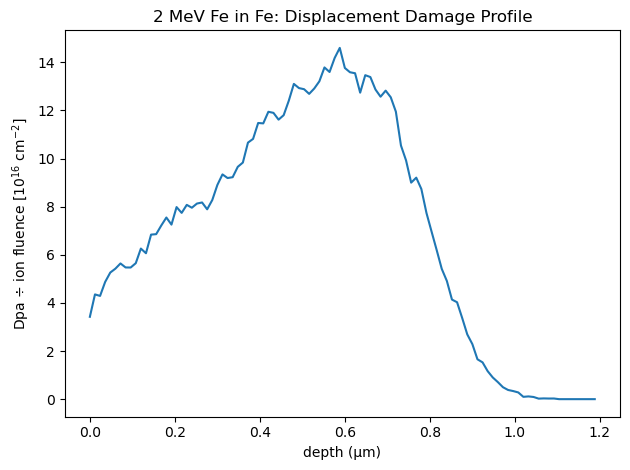

In [19]:
# Convert vacancies/ion to dpa/10^16 ions/cm^2
F0 = 1e16;  # ion flux
dx = (x[1]-x[0])*1e-7 # x grid step in cm 

# Plot
plt.figure()
plt.plot(x*1e-3, v*(F0/dx/Nfe))
plt.xlabel("depth (μm)")
plt.ylabel(r"Dpa $\div$ ion fluence [10$^{16}$ cm$^{-2}$]")
plt.title("2 MeV Fe in Fe: Displacement Damage Profile")
plt.tight_layout()
plt.show()